In [76]:
import numpy as np
import pandas as pd
import glob
from numba import guvectorize
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
from datetime import datetime, timezone
import re
import json
import awkward as ak
import pygama 


from dbetto import Props
from legendmeta import LegendMetadata
from lgdo import lh5
import lgdo
from dspeed.vis.waveform_browser import WaveformBrowser
from pygama.pargen.dsp_optimize import run_one_dsp
import lgdo.types as lgdo_types
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.patches as mpatches
from collections import defaultdict
from pathlib import Path

import itertools
from tqdm import tqdm
import time

# path to data

In [3]:
data_path = "/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest"
config = Props.read_from(os.path.join(data_path, "config.json"), subst_pathvar=True)["setups"]["l200"]["paths"]


In [4]:
lmeta  = LegendMetadata(config["metadata"])


In [5]:
chmap = ak.Array(lmeta.channelmap(lmeta.dataprod.runinfo.p03.r000.phy.start_key).group("system").geds.values())

In [6]:
lmeta.datasets.ovbb_partitions_pars.keys();

In [7]:
detector = "V02160A"
chn = chmap.daq.rawid[chmap.name == detector][0]

## Generate background 

(from Raoul notebook)

In [8]:
pet_files = sorted(glob.glob(f"{config['tier_pet']}/phy/l200-p0[346789]-*-phy-tier_pet.lh5"))


In [9]:
pet_files; 
# lista di tutti i path per tutti i periodi e tutti i run

In [10]:
# Load in event data. We will get:
# - coincident tells us if an event was a pulser, ged, or spm event
# - geds contains all info related to the geds system such as quality uts, PSD, detector statuses, and energy
# - trigger contains forced triggers and the timestamps for every event

In [11]:
start = time.time()  

# dentro ai file, vai al path degli evt e prendi solo i coicident, geds, trigger dai file pet
# così dagli eventi di germanio posso togliere eventi di pulser e di forced trigger
data_init = lh5.read_as("/evt", pet_files, field_mask=["coincident", "geds", "trigger"], library="ak")
print("Took", time.time() - start, "s to read")


Took 81.30900740623474 s to read


In [12]:
ak.fields(data_init.geds.quality.is_not_bb_like)

['is_delayed_discharge',
 'rawid',
 'is_empty_bits',
 'is_pos_polarity_bits',
 'is_highly_pos_polarity_bits',
 'is_neg_polarity_bits']

## Browsing the data : example --> discharges

In [13]:
def get_file_and_idx(timestamp, files):
    """ 
    Takes a provided event timestamp and determines which raw file the event occured in 
    and which event in that raw file corresponds to the event.
    """
    
    file_timestamps = [datetime.strptime(os.path.basename(file).split("-")[4], "%Y%m%dT%H%M%SZ").replace(tzinfo=timezone.utc).timestamp() for file in files]
    
    diffs = np.subtract(file_timestamps, timestamp)
    file_idx = list(diffs).index(diffs[diffs > 0][0]) - 1 # The -1 is necessary to handle an issue with time-zone mismatches between the file and event timestamps
    hit_tstamps = lh5.read('ch1104000/raw/timestamp', files[file_idx])
    hit_idx = np.searchsorted(hit_tstamps, timestamp)

    return file_idx, hit_idx

In [14]:
# ATTENZIONE STAI LAVORANDO A LIVELLO DI HIT (OGNI SINGOLA WAVEFORM)--> VANNO APPLICATI TUTTI I QC

In [15]:
data_init.geds.quality.is_not_bb_like.is_highly_pos_polarity_bits

<Array [[], [], [], [], ..., [], [], [], []] type='15721122 * var * float64'>

In [18]:
selection = data_init.geds.quality.is_not_bb_like.is_delayed_discharge;

selection = ak.all(data_init.geds.quality.is_good_channel, axis=-1)
selection = data_init.geds.quality.is_not_bb_like.is_delayed_discharge
selection;

In [19]:
timestamps = data_init[selection].trigger.timestamp

In [20]:
raw_ids = data_init[selection].geds.rawid

In [21]:
raw_files = sorted(glob.glob(f"{config['tier_raw']}/phy/*/*/*.lh5"))

In [22]:
channel_map = lmeta.channelmap(lmeta.dataprod.runinfo.p03.r000.phy.start_key)

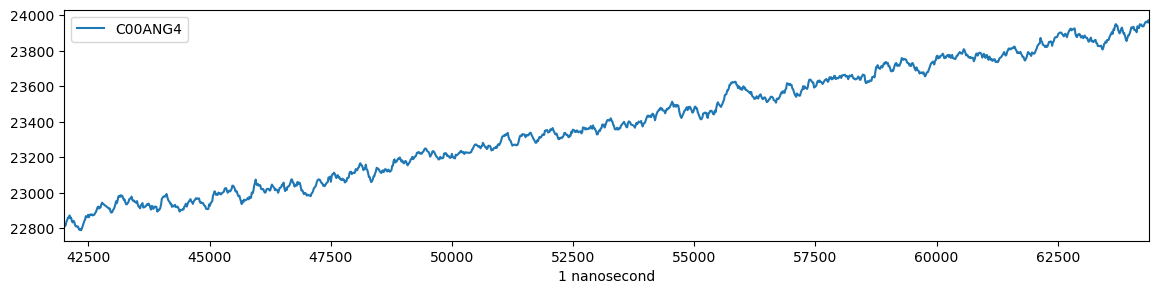

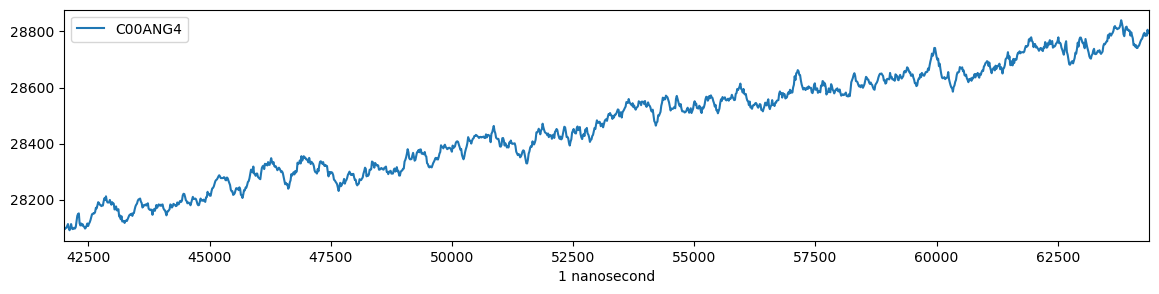

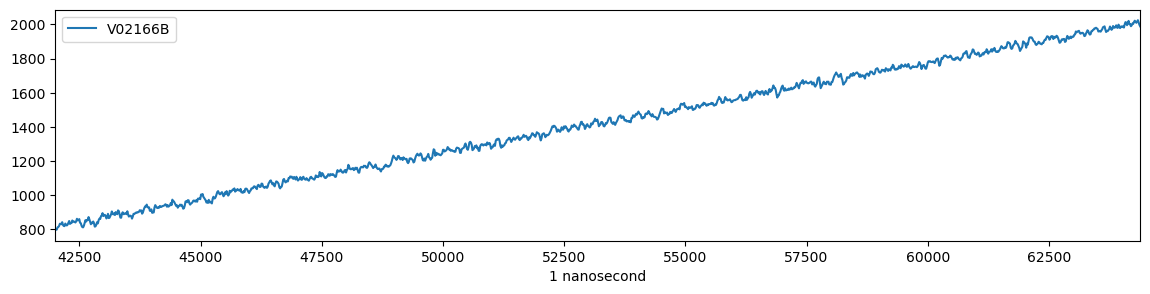

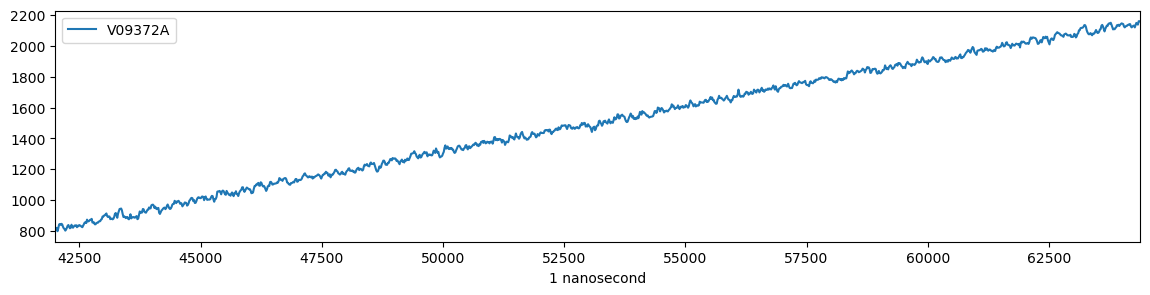

In [23]:
plt.rcParams["figure.figsize"] = (14, 3)
for timestamp, rawid in zip(timestamps[10:14], raw_ids[10:14]):

    if len(rawid) == 0:
        continue

    det = int(rawid[0])

    file_idx, hit_idx = get_file_and_idx(timestamp, raw_files)

    browser = WaveformBrowser(
        raw_files[file_idx],
        f'ch{det}/raw',
        lines=["waveform_windowed"],
        legend=[channel_map.map('daq.rawid')[det]['name']]
    )

    browser.draw_entry(hit_idx)

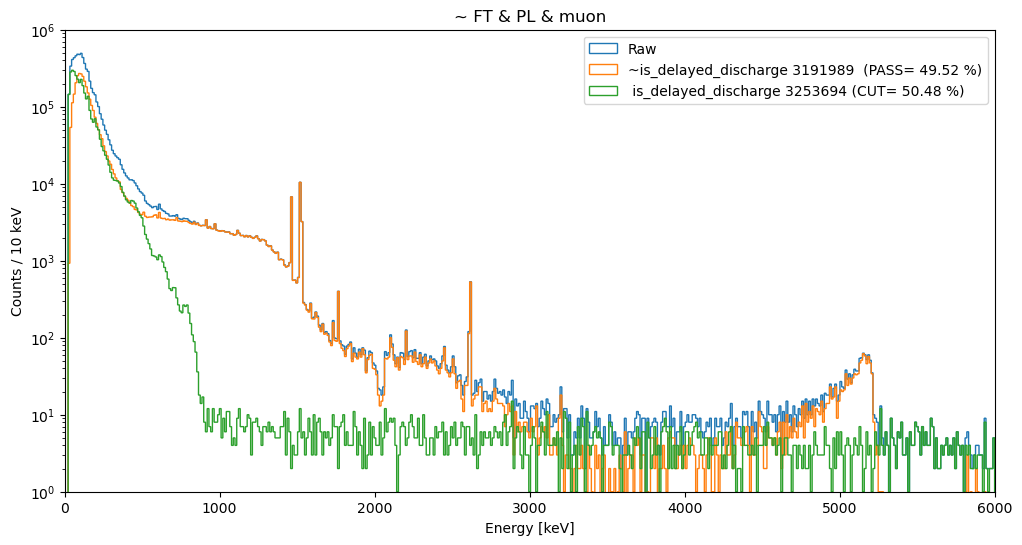

In [24]:
_, ax = plt.subplots(figsize = (12,6))
coincidence = ~data_init.trigger.is_forced & ~data_init.coincident.puls & ~data_init.coincident.muon_offline &  data_init.coincident.geds & ak.all(data_init.geds.quality.is_good_channel, axis=-1)
PASS = len(data_init.geds.energy_sum[coincidence & ~selection])*100/len(data_init.geds.energy_sum[coincidence])
CUT = len(data_init.geds.energy_sum[coincidence & selection])*100/len(data_init.geds.energy_sum[coincidence])
ax.hist(data_init.geds.energy_sum[coincidence], bins = 535, range = (0, 6000), histtype = 'step', label = "Raw")
ax.hist(data_init.geds.energy_sum[coincidence & ~selection], bins = 535, range = (0, 6000), histtype = 'step', label = f"~is_delayed_discharge {len(data_init.geds.energy_sum[coincidence & ~selection]) }  (PASS= {PASS:.2f} %)")
ax.hist(data_init.geds.energy_sum[coincidence & selection], bins = 535, range = (0, 6000), histtype = 'step', label = f" is_delayed_discharge {len(data_init.geds.energy_sum[coincidence & selection])} (CUT= {CUT:.2f} %)")
#ax.hist(data_init.geds.energy_sum[~selection &  ], bins = 535, range = (0, 5350), histtype = 'step', label = "No discarge  + No FC/PT/muon")
ax.set_title("~ FT & PL & muon")

ax.set_ylabel("Counts / 10 keV")
ax.set_xlabel("Energy [keV]")
ax.set_xlim(0, 6000)
ax.set_ylim(1, 1e6)
ax.set_yscale('log')
ax.legend()

-------

# Baseline slope

In [47]:
detector = "B00035B"
chn = chmap.daq.rawid[chmap.name == detector][0]
int(chn)

1084800

In [36]:
config['tier_raw']
fft_files = sorted(glob.glob(f"{config['tier_raw']}/fft/p08/r004/l200-p08-r004-fft-20231030T184107Z-tier_raw.lh5"))


In [44]:
for f in fft_files:
    print("\nFILE:", f)
    lh5.show(f)


FILE: /global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest/../v0.1.0/generated/tier/raw/fft/p08/r004/l200-p08-r004-fft-20231030T184107Z-tier_raw.lh5
/
├── FCConfig · table{packet_id,packet_len,readout_id,fcid,telid,nadcs,ntriggers,nsamples,adcbits,sumlength,blprecision,mastercards,triggercards,adccards,gps,ch_board_id,ch_inputnum,board_rev,board_uid} 
│   ├── adcbits · array<1>{real} 
│   ├── adccards · array<1>{real} 
│   ├── blprecision · array<1>{real} 
│   ├── board_rev · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 
│   │   └── flattened_data · array<1>{real} 
│   ├── board_uid · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 
│   │   └── flattened_data · array<1>{real} 
│   ├── ch_board_id · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 
│   │   └── flattened_data · array<1>{real} 
│   ├── ch_inputnum · array<1>{array<1>{real}} 
│   │   ├── cumulative_length · array<1>{real} 


In [53]:
start = time.time()
data_init = lh5.read_as(f"/ch{int(chn)}/raw", fft_files, field_mask = ["waveform_presummed"], library="ak")
print("Took", time.time() - start, "s to read")

Took 0.1261897087097168 s to read


In [54]:
data_init

<Array [{waveform_presummed: {...}}, ...] type='6565 * {waveform_presummed:...'>

In [90]:
ev = data_init[0]

wf  = ev.waveform_presummed

In [91]:
wf

<Record {t0: 0, dt: 128, values: [...]} type='{t0: float32, dt: float32, va...'>

In [106]:
def fit_baseline_single(wf, i_start=10, i_end=len(wf["values"]), order=1):
    """
    Polynomial fit of baseline for a single waveform.

    Parameters
    ----------
    wf : dict or awkward record
        Must contain:
        - wf["values"]
    i_start, i_end : int
        Fit range in samples
    order : int
        Polynomial order

    Returns
    -------
    dict with baseline parameters
    """
    import numpy as np
    from numpy.polynomial.polynomial import polyfit

    # extract waveform
    y = np.asarray(wf["values"])

    # x axis for fit
    x = np.arange(i_start, i_end)

    # slice waveform
    y_slice = y[i_start:i_end]

    # polynomial fit
    pol = polyfit(x, y_slice, order)

    # output container
    calcs = {
        "bl_int": pol[0],
        "bl_slope": pol[1] if order > 0 else 0.0
    }

    return calcs

In [107]:
calcs = {}
calcs = fit_baseline_single(wf)
calcs

{'bl_int': np.float64(120458.36745721629),
 'bl_slope': np.float64(0.09872128703971579)}

In [111]:
len(waves)


1024

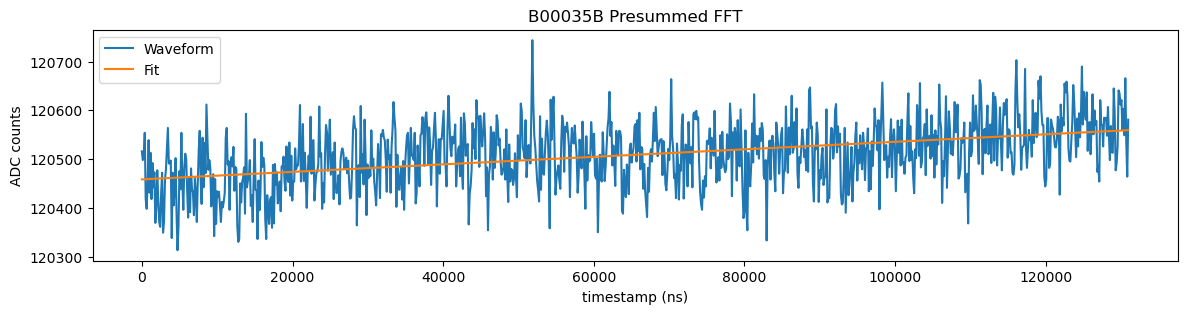

In [113]:
waves = wf["values"]
t0 = wf["t0"]
dt = wf["dt"]

timestamp = t0 + np.arange(len(waves)) * dt

x_fit = np.arange(len(waves))

baseline = calcs['bl_int'] + calcs['bl_slope'] * x_fit

plt.plot(timestamp, waves, label = "Waveform")
plt.plot(timestamp, baseline, label = "Fit")
plt.xlabel("timestamp (ns)")
plt.ylabel("ADC counts")
plt.legend(loc = "upper left")
plt.title(f"{detector} Presummed FFT")
plt.show()

-------------

In [64]:
is_pos = data_init.geds.quality.is_not_bb_like.is_pos_polarity_bits
is_hig = data_init.geds.quality.is_not_bb_like.is_highly_pos_polarity_bits

extra_qc = (
    ak.fill_none((ak.num(is_pos) == 1) & (ak.firsts(is_pos) == 123), False)
    |
    ak.fill_none((ak.num(is_hig) == 1) & (ak.firsts(is_hig) == 507), False)
)

In [70]:
data = data_init[
    ~data_init.trigger.is_forced &       # escludo eventi con calibrazione forzata
    ~data_init.coincident.puls &         # escludo eventi di pulser
    ~data_init.coincident.muon_offline & # escludo eventi con coincidenza di muoni
    data_init.coincident.geds &          # sono eventi con soli segnali da HPGe
    #(data_init.geds.quality.is_bb_like | extra_qc) &  # eventi di QC OPPURE  del nuovo Qc
    ak.all(data_init.geds.quality.is_good_channel, axis=-1)  # solo eventi con FULLY USABALE CHANNELS
]

In [66]:
dataQC = data_init[
    ~data_init.trigger.is_forced &       # escludo eventi con calibrazione forzata
    ~data_init.coincident.puls &         # escludo eventi di pulser
    ~data_init.coincident.muon_offline & # escludo eventi con coincidenza di muoni
    data_init.coincident.geds &          # tengo eventi che hanno almeno 1 hit
    (data_init.geds.quality.is_bb_like ) &  # eventi di QC OPPURE  del nuovo Qc
    ak.all(data_init.geds.quality.is_good_channel, axis=-1)  # prendop tutti i canali buoni
]

In [67]:
# Prendendo le energie in questo modos timao guardando al livelllo di hit_tier
# se volessi a livello di evet devo prendere la somma delle energie e non il singolo deposito
mydet = (ak.num(data.geds.rawid, axis=1) == 1) & (data.geds.rawid[:, 0] == chn)
events = data[mydet]
ene = events[ak.any((events.geds.rawid == chn), axis=1)].geds.energy

In [68]:
mydetQC = (ak.num(dataQC.geds.rawid, axis=1) == 1) & (dataQC.geds.rawid[:, 0] == chn)
eventsQC = dataQC[mydetQC]
eneQC = eventsQC[ak.any((eventsQC.geds.rawid == chn), axis=1)].geds.energy

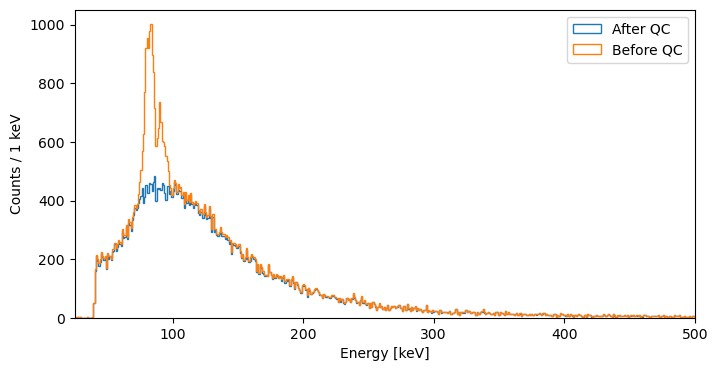

In [72]:
_, ax = plt.subplots(figsize = (8, 4))
Emin = 25
Emax = 500
bins = int(Emax)

ax.hist(eneQC, bins = bins, range = (Emin, Emax), histtype = 'step', label = "After QC")
ax.hist(ene, bins = bins, range = (Emin, Emax), histtype = 'step', label = "Before QC")

ax.legend()
ax.set_ylabel("Counts / 1 keV")
ax.set_xlabel("Energy [keV]")
ax.set_xlim(Emin, Emax)
#ax.set_yscale('log')
#ax.legend()
plt.show()